# Feature Selection Techniques

Every dataset has columns. Some columns help a model make good predictions.
Some columns barely help. Some columns can even confuse the model.

**Feature selection** means picking the best columns to keep, and dropping
the rest.

Why bother?
- Fewer columns can mean a simpler, faster model.
- Fewer columns can mean less overfitting. Overfitting is when a model
  memorizes noise in the training data instead of learning a real pattern.
- Fewer columns are easier for a human to read and explain.

This notebook covers two feature selection methods: **Forward Selection**
and **Backward Elimination**. Both methods work the same basic way: they
train many small models and compare their scores, to find which columns
are actually pulling their weight.

We use `diabetes.csv`. The goal is to predict `Outcome` (`1` = diabetic,
`0` = not diabetic) from five health measurements: `Glucose`,
`BloodPressure`, `SkinThickness`, `BMI`, and `Age`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

## Step 1 — Look at the data

In [2]:
dataset = pd.read_csv("diabetes.csv")
dataset.head()

,Glucose,BloodPressure,SkinThickness,BMI,Age,Outcome
0,148,72,35,33.6,50,1
1,85,66,29,26.6,31,0
2,183,64,0,23.3,32,1
3,89,66,23,28.1,21,0
4,137,40,35,43.1,33,1


In [3]:
dataset.shape

(768, 6)

768 rows, 6 columns. Before we select features, we should make sure the
data is clean. Feature selection only makes sense if the columns
themselves are trustworthy.

In [4]:
dataset.isnull().sum()

Glucose          0
BloodPressure    0
SkinThickness    0
BMI              0
Age              0
Outcome          0
dtype: int64

No missing values anywhere. Every column is ready to use as-is.

## Step 2 — What does "training a model" actually mean?

A model is not magic. It is a formula that turns input numbers (like
`Glucose`, `BMI`, `Age`) into an output (like `Outcome`).

At the start, the model does not know the right formula. **Training**
means showing the model many rows where we already know the true answer.
The model looks at those rows and adjusts itself so its guesses match
the true answers as closely as possible.

Once trained, we test the model on rows it has **never seen before**. If
it still gets the answer right most of the time, it has learned a real
pattern, not just memorized the training rows.

## Step 3 — Split the data: train vs test

We split the 768 rows into two groups:
- **Train set** — the model learns from these rows.
- **Test set** — the model is checked on these rows, which it never saw
  during training.

If we tested on the same rows we trained on, the model could just
memorize the answers and look perfect, even if it learned nothing
useful. Testing on unseen rows is what makes the score trustworthy.

We also pass `stratify=y`. `Outcome` is not a 50/50 split of diabetic vs
not diabetic, so `stratify=y` makes sure the train set and the test set
both keep roughly the same mix of `1`s and `0`s.

In [5]:
X = dataset.drop(columns=["Outcome"])
y = dataset["Outcome"]

In [6]:
X,y

(     Glucose  BloodPressure  SkinThickness   BMI  Age
 0        148             72             35  33.6   50
 1         85             66             29  26.6   31
 2        183             64              0  23.3   32
 3         89             66             23  28.1   21
 4        137             40             35  43.1   33
 ..       ...            ...            ...   ...  ...
 763      101             76             48  32.9   63
 764      122             70             27  36.8   27
 765      121             72             23  26.2   30
 766      126             60              0  30.1   47
 767       93             70             31  30.4   23
 
 [768 rows x 5 columns],
 0      1
 1      0
 2      1
 3      0
 4      1
       ..
 763    0
 764    0
 765    0
 766    1
 767    0
 Name: Outcome, Length: 768, dtype: int64)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((614, 5), (154, 5))

### What just happened here

`train_test_split` takes `X` and `y`, shuffles the rows — keeping each
row of `X` lined up with its matching row of `y` — and then cuts the
shuffled rows into two groups. It always hands back **4 pieces, in this
exact order**:

`X_train, X_test, y_train, y_test`

That order matters. Since we wrote `X_train, X_test, y_train, y_test =
...` on the left, Python just matches them up position by position —
swap the order on the left and you'd silently get inputs and answers
mixed up.

Here's what each argument did:

- **`test_size=0.2`** — put 20% of the rows in the test group, 80% in
  the train group. `768 × 0.2 ≈ 154` and `768 × 0.8 ≈ 614` — exactly
  what `.shape` printed above.
- **`random_state=42`** — the shuffle is random, but this number is a
  seed for that randomness. It makes the shuffle land the same way
  every time this cell reruns, instead of a different split each time.
- **`stratify=y`** — without this, a random shuffle could get unlucky
  and put too many (or too few) diabetic patients into one group by
  chance. `stratify=y` forces the train group and the test group to
  each keep roughly the same percentage of `Outcome == 1` as the full
  dataset.

Let's check that `stratify=y` actually worked, instead of just trusting it.

In [8]:
y.value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [9]:
y_train.value_counts(normalize=True)

Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

In [10]:
y_test.value_counts(normalize=True)

Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64

All three are close to **65% not diabetic / 35% diabetic** — the full
dataset, the train set, and the test set. That's `stratify=y` doing its
job: without it, one of these splits could easily have drifted to, say,
60/40 or 70/30 just from random luck.

## Step 4 — Pick one model to reuse

Feature selection needs to train the *same kind* of model over and over,
once per feature combination, so the scores are comparable. We'll use a
**Decision Tree Classifier**.

A decision tree works like a flowchart of yes/no questions. For example:
*"Is Glucose above 140?"* → yes or no → next question → ... → until it
reaches a final answer: diabetic or not diabetic. Training a tree means
figuring out which questions to ask, and in what order, so it sorts the
training rows correctly as often as possible.

We cap the tree at `max_depth=4` — at most 4 questions deep. A tree with
no limit can grow a question for almost every single row, which is just
memorizing, not learning. Capping the depth keeps it honest.

In [11]:
baseline_model = DecisionTreeClassifier(max_depth=4, random_state=42)

In [12]:
baseline_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

The line above is the actual **training** step. `.fit()` shows the model
the training rows together with their true `Outcome`, and the model
builds its flowchart of questions from that.

In [13]:
y_pred = baseline_model.predict(X_test)

In [14]:
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_accuracy

0.8051948051948052

That's our **baseline**: one Decision Tree, trained on **all 5 features**,
scores about 80.5% accuracy on the test rows it never saw during
training. Every feature selection result below gets compared back to
this number.

## Step 5 — Do we actually need all 5 features?

Maybe. Maybe not. Some features might barely help the tree, or might even
distract it. The only way to know is to try different combinations and
compare their scores — which is exactly what "training a model" meant in
Step 2, just repeated many times over.

Both `SequentialFeatureSelector` methods below follow the same loop at
every step:

```mermaid
flowchart LR
    A[Current feature set] --> B[Try each candidate feature]
    B --> C[Train + cross-validate\none model per candidate]
    C --> D[Compare average scores]
    D --> E[Keep the best-scoring feature]
    E --> F{Reached target\nfeature count?}
    F -- No --> A
    F -- Yes --> G[Done: final feature set]
    style A fill:#2a78d6,color:#fff
    style G fill:#2f9e6f,color:#fff
```

**Cross-validate** means: instead of judging a candidate on one single
train/check split, the training data itself is cut into 5 chunks
(`cv=5`). The model trains on 4 chunks and checks itself on the 5th —
five times, rotating which chunk is held out — and the 5 scores get
averaged. This is more reliable than a single score, because it is not
just luck of one particular split.

So yes — this really does train a small model for every candidate
feature, on every fold, at every step. For 5 features and `cv=5`, the
forward search below trains roughly:

| step | candidate features left | models trained (× 5 folds) |
|---|---|---|
| pick 1st feature | 5 | 25 |
| pick 2nd feature | 4 | 20 |
| pick 3rd feature | 3 | 15 |
| pick 4th feature | 2 | 10 |
| pick 5th feature | 1 | 5 |
| **total** | | **~75** |

That matches what you saw in the video screenshots — every little box
with an "Acc: .." number next to it was one of these trained models.
`mlxtend` just does that same search automatically instead of by hand.

## Step 6 — Forward Selection

Forward Selection starts with **zero** features and adds one at a time:

1. Try each feature alone. Train + cross-validate. Keep whichever single
   feature scores best.
2. Try adding each *remaining* feature to that winner. Keep whichever
   pair scores best.
3. Keep repeating — always adding one more feature — until we've built
   up to the full feature count.

`k_features=(1, 5)` tells `mlxtend` to search that whole range (1 feature
up to all 5), so we can see the score at every step, not just one fixed
size.

In [15]:
sfs_forward = SFS(
    DecisionTreeClassifier(max_depth=4, random_state=42),
    k_features=(1, X.shape[1]),
    forward=True,
    floating=False,
    scoring="accuracy",
    cv=5,
)

In [16]:
sfs_forward.fit(X_train, y_train)

/Users/kaliprasad/Documents/MACHINE_LEARNING/.venv/lib/python3.14/site-packages/sklearn/externals/_numpydoc/docscrape.py:203: UserWarning: potentially wrong underline length... 
Examples 
----------- in 
Sequential Feature Selection for Classification and Regression.
...
  while not self._is_at_section() and not self._doc.eof():


,estimator,DecisionTreeC...ndom_state=42)
,k_features,"(1, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [17]:
forward_table = pd.DataFrame(sfs_forward.subsets_).T
forward_table

,feature_idx,cv_scores,avg_score,feature_names
1,"(0,)","[0.7642276422764228, 0.7073170731707317, 0.691...",0.739504,"(Glucose,)"
2,"(0, 1)","[0.7642276422764228, 0.7398373983739838, 0.707...",0.749247,"(Glucose, BloodPressure)"
3,"(0, 1, 2)","[0.7560975609756098, 0.7479674796747967, 0.707...",0.752526,"(Glucose, BloodPressure, SkinThickness)"
4,"(0, 1, 2, 3)","[0.7398373983739838, 0.7073170731707317, 0.707...",0.739491,"(Glucose, BloodPressure, SkinThickness, BMI)"
5,"(0, 1, 2, 3, 4)","[0.7154471544715447, 0.6991869918699187, 0.707...",0.72487,"(Glucose, BloodPressure, SkinThickness, BMI, Age)"


Read this table top to bottom — it's the step-by-step trace:

1. `Glucose` alone → **73.95%**
2. `+ BloodPressure` → **74.92%** (better, keep going)
3. `+ SkinThickness` → **75.25%** (best score in the whole table)
4. `+ BMI` → **73.95%** (worse — adding BMI actually hurt)
5. `+ Age` (all 5 features) → **72.49%** (worse again)

The score peaks at **3 features** and then goes *down*. That's the whole
point of feature selection: `BMI` and `Age` were not helping this model —
they were adding noise the tree had to work around.

In [18]:
forward_features = list(sfs_forward.k_feature_names_)
forward_features

['Glucose', 'BloodPressure', 'SkinThickness']

In [19]:
sfs_forward.k_score_

np.float64(0.752525656404105)

## Step 7 — Backward Elimination

Backward Elimination is the mirror image. It starts with **all**
features and removes one at a time:

1. Train + cross-validate on the full feature set.
2. Try removing each feature, one at a time. Train + cross-validate each
   reduced set. Remove whichever feature hurts the score the least (or
   helps it the most).
3. Keep repeating — always removing one more feature — down to a single
   feature.

In [20]:
sfs_backward = SFS(
    DecisionTreeClassifier(max_depth=4, random_state=42),
    k_features=(1, X.shape[1]),
    forward=False,
    floating=False,
    scoring="accuracy",
    cv=5,
)

In [21]:
sfs_backward.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,k_features,"(1, ...)"
,forward,False
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [22]:
backward_table = pd.DataFrame(sfs_backward.subsets_).T
backward_table

,feature_idx,cv_scores,avg_score,feature_names
5,"(0, 1, 2, 3, 4)","[0.7154471544715447, 0.6991869918699187, 0.707...",0.72487,"(Glucose, BloodPressure, SkinThickness, BMI, Age)"
4,"(0, 1, 2, 3)","[0.7398373983739838, 0.7073170731707317, 0.707...",0.739491,"(Glucose, BloodPressure, SkinThickness, BMI)"
3,"(0, 1, 2)","[0.7560975609756098, 0.7479674796747967, 0.707...",0.752526,"(Glucose, BloodPressure, SkinThickness)"
2,"(0, 1)","[0.7642276422764228, 0.7398373983739838, 0.707...",0.749247,"(Glucose, BloodPressure)"
1,"(0,)","[0.7642276422764228, 0.7073170731707317, 0.691...",0.739504,"(Glucose,)"


Read this one top to bottom too — the row order (5 → 1) is the trace of
what got **removed** at each step, ending with the smallest set at the
bottom:

- All 5 features → **72.49%**
- Remove `Age` → 4 left → **73.95%** (better — `Age` wasn't helping)
- Remove `BMI` → 3 left → **75.25%** (best score again)
- Remove `SkinThickness` → 2 left → 74.92%
- Remove `BloodPressure` → 1 left (`Glucose` only) → 73.95%

Notice something: **forward and backward landed on the exact same 3
features** (`Glucose`, `BloodPressure`, `SkinThickness`), and the score
at every feature-count matches between the two tables. That's not
guaranteed — it happened here because we only had 5 candidate features
to begin with, so both searches had very little room to disagree. With
more features, forward and backward can (and often do) pick different
subsets.

In [23]:
backward_features = list(sfs_backward.k_feature_names_)
backward_features

['Glucose', 'BloodPressure', 'SkinThickness']

## Step 8 — Visualize: accuracy vs. number of features

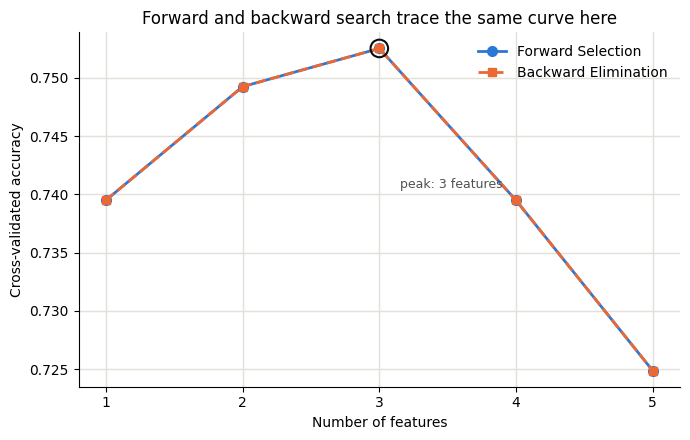

In [24]:
forward_scores = forward_table["avg_score"].astype(float)
backward_scores = backward_table.sort_index()["avg_score"].astype(float)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(forward_table.index.astype(int), forward_scores,
        color="#2a78d6", linewidth=2, marker="o", markersize=7,
        label="Forward Selection")
ax.plot(backward_table.sort_index().index.astype(int), backward_scores,
        color="#eb6834", linewidth=2, linestyle="--", marker="s", markersize=6,
        label="Backward Elimination")

best_k = forward_scores.astype(float).idxmax()
ax.scatter([int(best_k)], [forward_scores.loc[best_k]], s=160,
           facecolors="none", edgecolors="#0b0b0b", linewidths=1.5, zorder=5)
ax.annotate(f"peak: {best_k} features", xy=(int(best_k), forward_scores.loc[best_k]),
            xytext=(int(best_k) + 0.15, forward_scores.loc[best_k] - 0.012),
            fontsize=9, color="#52514e")

ax.set_xlabel("Number of features")
ax.set_ylabel("Cross-validated accuracy")
ax.set_title("Forward and backward search trace the same curve here")
ax.set_xticks(range(1, X.shape[1] + 1))
ax.grid(True, color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

The dashed orange line sits exactly on top of the solid blue line at
every point — that's the "forward and backward agree" finding from Step
7, made visible. Both curves rise to a peak at 3 features, then fall as
`BMI` and `Age` get added back in.

## Step 9 — Build the final models and check on the test set

The tables above show **cross-validated** scores from the training data.
Now let's actually build a model using only the selected features, and
check it against the untouched test set — the real, final check.

In [25]:
final_forward_model = DecisionTreeClassifier(max_depth=4, random_state=42)
final_forward_model.fit(X_train[forward_features], y_train)
forward_test_accuracy = accuracy_score(
    y_test, final_forward_model.predict(X_test[forward_features])
)
forward_test_accuracy

0.7012987012987013

In [26]:
final_backward_model = DecisionTreeClassifier(max_depth=4, random_state=42)
final_backward_model.fit(X_train[backward_features], y_train)
backward_test_accuracy = accuracy_score(
    y_test, final_backward_model.predict(X_test[backward_features])
)
backward_test_accuracy

0.7012987012987013

## A surprising result — and an important lesson

Look closely: the 3-feature model scores **lower** on the test set
(about 70.1%) than the baseline model trained on **all 5 features**
(about 80.5%) — even though the 3-feature model had the *better*
cross-validated score during selection (75.25% vs 72.49%).

That looks like a contradiction. It isn't — it's a lesson about what
each number actually measures:

- The **cross-validated score** is an average over 5 different chunks
  of the *training* data. It's a good guide for comparing feature sets,
  because it averages out some randomness.
- The **test-set score** comes from just *one* fixed set of 154 rows.
  With that few rows, a handful of flipped predictions can swing the
  percentage by several points — 16 rows out of 154 is the entire gap
  here.

So feature selection did what it promised: it found a smaller feature
set that scores about as well *on average* as the full set, using 2
fewer columns. It never promised to beat the full model on any one
particular test split — and here, on this split, it didn't. This is
exactly why cross-validation, not a single train/test split, is what
`SequentialFeatureSelector` uses internally to make its choice.

## Step 10 — Compare all three models

In [27]:
comparison = pd.DataFrame({
    "features_used": [X.shape[1], len(forward_features), len(backward_features)],
    "test_accuracy": [baseline_accuracy, forward_test_accuracy, backward_test_accuracy],
}, index=["All features (baseline)", "Forward Selection", "Backward Elimination"])
comparison

,features_used,test_accuracy
All features (baseline),5,0.805195
Forward Selection,3,0.701299
Backward Elimination,3,0.701299


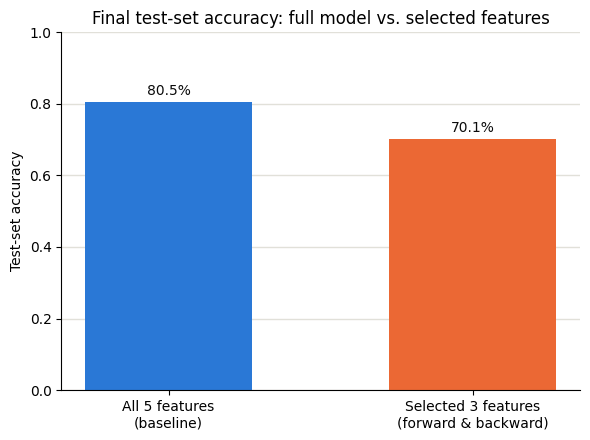

In [28]:
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(
    ["All 5 features\n(baseline)", "Selected 3 features\n(forward & backward)"],
    [baseline_accuracy, forward_test_accuracy],
    color=["#2a78d6", "#eb6834"],
    width=0.55,
)
ax.set_ylabel("Test-set accuracy")
ax.set_ylim(0, 1)
ax.set_title("Final test-set accuracy: full model vs. selected features")
ax.grid(True, axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for bar, value in zip(bars, [baseline_accuracy, forward_test_accuracy]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{value:.1%}", ha="center", fontsize=10, color="#0b0b0b")

plt.tight_layout()
plt.show()

## Key takeaways

- **Feature selection = trying feature combinations and comparing
  scores.** Nothing more mysterious than that. `mlxtend` just automates
  the "try it, score it, keep the best" loop you saw in the video
  screenshots.
- **Forward Selection** starts empty and adds the best feature each
  round. Cheaper when you expect to keep only a few features out of
  many.
- **Backward Elimination** starts full and removes the least useful
  feature each round. Cheaper when you expect to keep most features and
  only drop a few.
- Both are **greedy** searches — they lock in a choice at each step and
  never look back. Neither is guaranteed to find the single best
  possible combination, but both are far cheaper than trying every
  combination (2⁵ = 32 here; it grows fast with more columns).
- Compare feature sets using the **cross-validated** score, not a single
  test-set number — a single test split can be noisy, as Step 9 showed.